<a href="https://colab.research.google.com/github/mocha-dts/DataScience_240401010041_M.Rochmatullah/blob/main/Pertemuan12_mochamadrochmatullah_240401010041.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama Lengkap  : Mochamad Rochmatullah
#### NIM           : 240401010041
#### Kelas         : IF403

# **Sesi 12 – Asosiasi Data & Sistem Rekomendasi Dasar**

#### STEP 1 — Generate & Eksplorasi Dataset Transaksi

In [23]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
filterwarnings('ignore')

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print("Contoh transaksi")
for i in range(5):
    print(f"Transaksi {i+1} :", transaksi[i])

print("Jumlah transaksi :", len(transaksi))

Contoh transaksi
Transaksi 1 : [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2 : [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3 : [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
Transaksi 4 : [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
Transaksi 5 : [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]
Jumlah transaksi : 50


In [24]:
# Mengubah Menjadi DataFrame

df_transaksi = pd.DataFrame({

    "ID_Transaksi": range(1,51),

    "Daftar_Item": [
        ", ".join(x)
        for x in transaksi
    ]
})

df_transaksi.head()

,ID_Transaksi,Daftar_Item
0,1,"Keju, Roti, Mentega, Kopi, Selai"
1,2,"Roti, Kopi, Teh, Selai, Mentega"
2,3,"Kopi, Susu, Teh"
3,4,"Selai, Keju, Telur, Teh"
4,5,"Mentega, Susu, Gula, Keju"


In [25]:
from collections import Counter

# Menghitung Frekuensi Produk

counter = Counter()
for trx in transaksi:
    counter.update(trx)

frekuensi = pd.DataFrame(
    counter.items(),
    columns=[
        "Produk",
        "Frekuensi"
    ]
)

frekuensi = frekuensi.sort_values(
    by="Frekuensi",
    ascending=False
)

frekuensi

,Produk,Frekuensi
4,Selai,26
5,Teh,23
2,Mentega,21
7,Telur,18
0,Keju,17
1,Roti,16
3,Kopi,16
6,Susu,16
8,Gula,16
9,Sereal,9


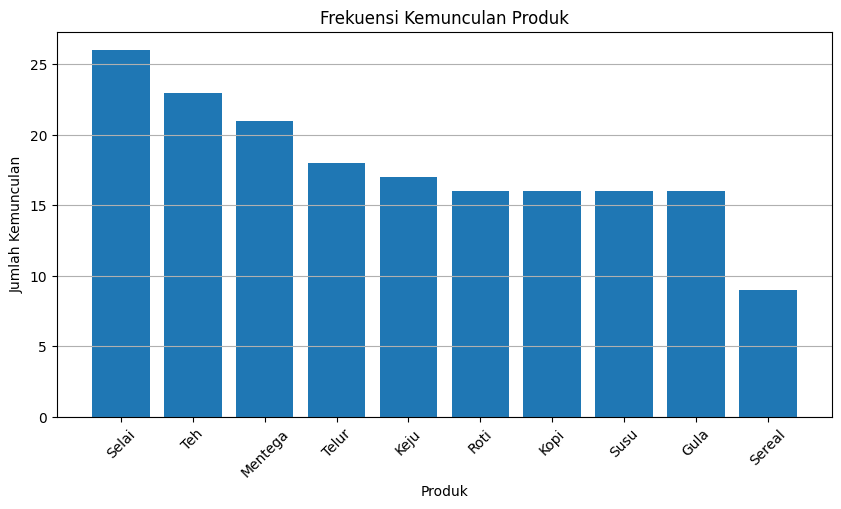

In [26]:
plt.figure(figsize=(10,5))
plt.bar(
    frekuensi["Produk"],
    frekuensi["Frekuensi"]
)

plt.title("Frekuensi Kemunculan Produk")
plt.xlabel("Produk")
plt.ylabel("Jumlah Kemunculan")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [27]:
print(
    "Produk paling sering muncul:",
    frekuensi.iloc[0]["Produk"]
)

print(
    "Frekuensi:",
    frekuensi.iloc[0]["Frekuensi"]
)

Produk paling sering muncul: Selai
Frekuensi: 26


#### STEP 2 — One-Hot Encoding Transaksi

In [28]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_ary, columns=te.columns_)

print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


#### STEP 3 — Cari Frequent Itemset dengan Apriori

In [29]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )

    print(f"min_support = {ms} : {len(freq)} itemset ditemukan")

min_support = 0.05 : 74 itemset ditemukan
min_support = 0.1 : 44 itemset ditemukan
min_support = 0.2 : 13 itemset ditemukan


In [34]:
freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    by="support",
    ascending=False
)

freq_items["Support (%)"] = (
    freq_items["support"] * 100
).round(2)

freq_items.head(10)

,support,itemsets,Support (%)
5,0.52,(Selai),52.0
8,0.46,(Teh),46.0
3,0.42,(Mentega),42.0
9,0.36,(Telur),36.0
1,0.34,(Keju),34.0
0,0.32,(Gula),32.0
2,0.32,(Kopi),32.0
4,0.32,(Roti),32.0
7,0.32,(Susu),32.0
36,0.24,"(Selai, Teh)",24.0


#### STEP 4 — Bentuk & Saring Aturan Asosiasi


In [36]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.6
)

print("Jumlah aturan :", len(rules))
rules.head()

Jumlah aturan : 10


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Roti),(Selai),0.32,0.52,0.22,0.687500,1.322115,1.0,0.0536,1.536,0.358289,0.354839,0.348958,0.555288
1,(Gula),(Selai),0.32,0.52,0.20,0.625000,1.201923,1.0,0.0336,1.280,0.247059,0.312500,0.218750,0.504808
2,(Sereal),(Mentega),0.18,0.42,0.14,0.777778,1.851852,1.0,0.0644,2.610,0.560976,0.304348,0.616858,0.555556
3,"(Telur, Teh)",(Keju),0.20,0.34,0.12,0.600000,1.764706,1.0,0.0520,1.650,0.541667,0.285714,0.393939,0.476471
4,"(Telur, Keju)",(Teh),0.16,0.46,0.12,0.750000,1.630435,1.0,0.0464,2.160,0.460317,0.240000,0.537037,0.505435


In [37]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head(10)

rules = rules.sort_values(
    by="confidence",
    ascending=False
)

rules.head(10)

rules["Support (%)"] = (
    rules["support"]*100
).round(2)

rules["Confidence (%)"] = (
    rules["confidence"]*100
).round(2)

rules.head(10)

best_rule = rules.iloc[0]

print("Antecedent :", best_rule["antecedents"])
print("Consequent :", best_rule["consequents"])
print("Support :", round(best_rule["support"],3))
print("Confidence :", round(best_rule["confidence"],3))
print("Lift :", round(best_rule["lift"],3))

Antecedent : frozenset({np.str_('Roti'), np.str_('Gula')})
Consequent : frozenset({'Selai'})
Support : 0.1
Confidence : 1.0
Lift : 1.923


In [41]:
for i, row in rules.iterrows():
    print("="*50)
    print(f"Rule {i+1}")
    print(f"{set(row['antecedents'])} --> {set(row['consequents'])}")
    print(f"Support    : {row['support']:.2f}")
    print(f"Confidence : {row['confidence']:.2f}")
    print(f"Lift       : {row['lift']:.2f}")

Rule 7
{np.str_('Roti'), np.str_('Gula')} --> {'Selai'}
Support    : 0.10
Confidence : 1.00
Lift       : 1.92
Rule 6
{np.str_('Teh'), np.str_('Keju')} --> {np.str_('Telur')}
Support    : 0.12
Confidence : 0.86
Lift       : 2.38
Rule 3
{np.str_('Sereal')} --> {np.str_('Mentega')}
Support    : 0.14
Confidence : 0.78
Lift       : 1.85
Rule 5
{np.str_('Telur'), np.str_('Keju')} --> {np.str_('Teh')}
Support    : 0.12
Confidence : 0.75
Lift       : 1.63
Rule 10
{'Selai', np.str_('Kopi')} --> {np.str_('Mentega')}
Support    : 0.10
Confidence : 0.71
Lift       : 1.70
Rule 9
{np.str_('Mentega'), np.str_('Kopi')} --> {'Selai'}
Support    : 0.10
Confidence : 0.71
Lift       : 1.37
Rule 1
{np.str_('Roti')} --> {'Selai'}
Support    : 0.22
Confidence : 0.69
Lift       : 1.32
Rule 2
{np.str_('Gula')} --> {'Selai'}
Support    : 0.20
Confidence : 0.62
Lift       : 1.20
Rule 8
{np.str_('Mentega'), 'Selai'} --> {np.str_('Kopi')}
Support    : 0.10
Confidence : 0.62
Lift       : 1.95
Rule 4
{np.str_('Telur

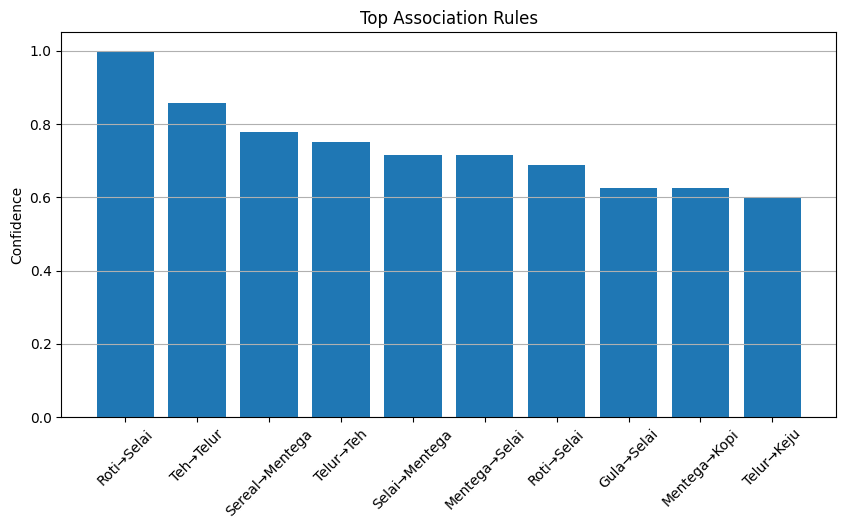

In [43]:
top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_rules)),
    top_rules["confidence"]
)

plt.xticks(
    range(len(top_rules)),
    [
        f"{list(a)[0]}→{list(c)[0]}"
        for a,c in zip(
            top_rules["antecedents"],
            top_rules["consequents"]
        )
    ],
    rotation=45
)

plt.ylabel("Confidence")
plt.title("Top Association Rules")
plt.grid(axis="y")
plt.show()

#### Aturan mana yang paling kuat (Lift tertinggi)?

In [46]:
rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift,Support (%),Confidence (%)
5,"(Teh, Keju)",(Telur),0.12,0.857143,2.380952,12.0,85.71
7,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125,10.0,62.50
6,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077,10.0,100.00
2,(Sereal),(Mentega),0.14,0.777778,1.851852,14.0,77.78
3,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706,12.0,60.00
9,"(Selai, Kopi)",(Mentega),0.10,0.714286,1.700680,10.0,71.43
4,"(Telur, Keju)",(Teh),0.12,0.750000,1.630435,12.0,75.00
8,"(Mentega, Kopi)",(Selai),0.10,0.714286,1.373626,10.0,71.43
0,(Roti),(Selai),0.22,0.687500,1.322115,22.0,68.75
1,(Gula),(Selai),0.20,0.625000,1.201923,20.0,62.50


*   Support = 12% berarti sebanyak 12% dari seluruh transaksi mengandung kombinasi Teh, Keju, dan Telur.
*   Confidence = 85,71% berarti 85,71% transaksi yang berisi Teh dan Keju juga mengandung Telur.
*   Lift = 2,38 berarti pelanggan yang membeli Teh dan Keju memiliki kemungkinan sekitar 2,38 kali lebih besar untuk membeli Telur dibandingkan jika pembelian Telur terjadi secara acak. Nilai lift yang lebih besar dari 1 menunjukkan hubungan asosiasi yang kuat.

#### Apakah masuk akal secara bisnis?

Aturan ini masih masuk akal secara bisnis karena teh, keju, dan telur merupakan produk yang dapat dikonsumsi bersamaan sebagai menu sarapan atau makanan ringan. Selain itu, aturan {Roti} → {Selai} juga memiliki hubungan yang logis karena kedua produk saling melengkapi, meskipun nilai lift-nya lebih rendah dibandingkan aturan pertama.

#### STEP 5 — Rekomender Sederhana dengan Content-Based Filtering

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

produk = pd.DataFrame({
    "Produk": [
        "Roti",
        "Selai",
        "Susu",
        "Keju",
        "Mentega",
        "Kopi",
        "Teh",
        "Sereal",
        "Telur",
        "Gula"
    ],
    "Kategori": [
        "Makanan Sarapan Roti",
        "Makanan Olesan Sarapan",
        "Minuman Susu",
        "Produk Olahan Susu",
        "Makanan Olesan Roti",
        "Minuman Panas",
        "Minuman Panas",
        "Makanan Sarapan",
        "Protein Sarapan",
        "Pemanis Minuman"
    ]
})

produk

,Produk,Kategori
0,Roti,Makanan Sarapan Roti
1,Selai,Makanan Olesan Sarapan
2,Susu,Minuman Susu
3,Keju,Produk Olahan Susu
4,Mentega,Makanan Olesan Roti
5,Kopi,Minuman Panas
6,Teh,Minuman Panas
7,Sereal,Makanan Sarapan
8,Telur,Protein Sarapan
9,Gula,Pemanis Minuman


In [64]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(
    produk["Kategori"]
)

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim
similarity_df = pd.DataFrame(
    cosine_sim,
    index=produk["Produk"],
    columns=produk["Produk"]
)

similarity_df
def rekomendasi(nama_produk, top_n=3):
    skor = similarity_df[nama_produk]
    rekom = skor.sort_values(
        ascending=False
    )[1:top_n+1]
    return rekom

hasil = rekomendasi("Roti").reset_index()
hasil.columns = [
    "Produk Rekomendasi",
    "Similarity"
]
hasil

,Produk Rekomendasi,Similarity
0,Sereal,0.739947
1,Mentega,0.668921
2,Selai,0.547521


#### STEP 6 — Bandingkan Kedua Pendekatan

In [85]:
print("=== Association Rule ===")
print("Jika pelanggan membeli: Roti")
print("Maka direkomendasikan: Selai")
print("Confidence : 68.75%")
print("Lift : 1.32")

print("\n")

print("=== Content-Based Filtering ===")
hasil = rekomendasi("Roti")
print(hasil)

=== Association Rule ===
Jika pelanggan membeli: Roti
Maka direkomendasikan: Selai
Confidence : 68.75%
Lift : 1.32


=== Content-Based Filtering ===
Produk
Sereal     0.739947
Mentega    0.668921
Selai      0.547521
Name: Roti, dtype: float64


In [86]:
perbandingan = pd.DataFrame({
    "Aspek": [
        "Dasar Rekomendasi",
        "Sumber Data",
        "Kelebihan",
        "Kekurangan"
    ],
    "Association Rule": [
        "Pola pembelian bersama",
        "Riwayat transaksi",
        "Menemukan kebiasaan pelanggan",
        "Perlu banyak data transaksi"
    ],
    "Content-Based": [
        "Kemiripan karakteristik produk",
        "Informasi atribut produk",
        "Tidak membutuhkan riwayat transaksi pengguna lain",
        "Bergantung pada kualitas atribut produk"
    ]
})

perbandingan

,Aspek,Association Rule,Content-Based
0,Dasar Rekomendasi,Pola pembelian bersama,Kemiripan karakteristik produk
1,Sumber Data,Riwayat transaksi,Informasi atribut produk
2,Kelebihan,Menemukan kebiasaan pelanggan,Tidak membutuhkan riwayat transaksi pengguna lain
3,Kekurangan,Perlu banyak data transaksi,Bergantung pada kualitas atribut produk


#### Apakah kedua pendekatan memberi rekomendasi yang konsisten?

Ya, secara umum kedua pendekatan memberikan rekomendasi yang konsisten, meskipun menggunakan cara kerja yang berbeda.

Pada Association Rule Mining (Apriori), rekomendasi diberikan berdasarkan pola pembelian pelanggan. Misalnya, aturan Roti → Selai menunjukkan bahwa pelanggan yang membeli roti juga cenderung membeli selai berdasarkan riwayat transaksi.

Sementara itu, Content-Based Filtering memberikan rekomendasi berdasarkan kemiripan karakteristik produk. Produk seperti Roti, Selai, dan Mentega memiliki kategori yang berkaitan dengan makanan sarapan sehingga direkomendasikan sebagai produk yang mirip.

Walaupun mekanismenya berbeda, kedua metode sama-sama menghasilkan rekomendasi yang logis, yaitu menghubungkan produk-produk yang saling melengkapi atau memiliki karakteristik serupa. Hal ini menunjukkan bahwa kedua pendekatan dapat saling mendukung dalam membangun sistem rekomendasi.

#### Kapan sebaiknya menggunakan salah satu, atau menggabungkan keduanya (Hybrid)?
*   Association Rule Mining lebih tepat digunakan apabila perusahaan memiliki data transaksi yang banyak. Metode ini efektif untuk menemukan pola pembelian pelanggan dan mendukung strategi seperti cross-selling, bundling produk, dan pengaturan tata letak produk di toko.
*   Content-Based Filtering lebih sesuai digunakan ketika tersedia informasi atau atribut produk yang lengkap, tetapi data transaksi masih sedikit atau belum cukup untuk menemukan pola pembelian. Metode ini juga berguna untuk merekomendasikan produk yang memiliki karakteristik serupa.
*   Hybrid Recommender System (gabungan kedua metode) merupakan pilihan yang paling baik ketika tersedia data transaksi sekaligus informasi atribut produk. Dengan menggabungkan kedua pendekatan, sistem dapat memberikan rekomendasi yang lebih akurat karena mempertimbangkan perilaku pembelian pelanggan serta kemiripan karakteristik produk. Pendekatan hybrid juga dapat mengatasi keterbatasan masing-masing metode jika digunakan secara terpisah.